In [132]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
import matplotlib.pyplot as plt
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Check for CUDA and if available, use that device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [112]:
def calculate_size(input_size, kernel_size, padding=0, stride=1):
    return( ( (input_size + 2*padding - (kernel_size -1) -1 ) /stride +1) )

In [175]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, conv_layers=3, batch_norm=False, dropout=False):
        super(SimpleCNN, self).__init__()

        print('-'*30)
        print('* Layers:')
        
        channels = 32
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        new_size = calculate_size(input_size = 32, kernel_size = 3, padding = 1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        new_size = calculate_size(input_size = new_size, kernel_size = 2, stride = 2)
        self.dropout1 = nn.Dropout2d(0.2)
        print(f'Layer 1 output: {new_size}*{new_size}, channels: {channels}')

        channels = 64
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        new_size = calculate_size(input_size = new_size, kernel_size = 3, padding = 1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        new_size = calculate_size(input_size = new_size, kernel_size = 2, stride = 2)
        self.dropout2 = nn.Dropout2d(0.2)
        print(f'Layer 2 output: {new_size}*{new_size}, channels: {channels}')

        if conv_layers >= 3:
            channels = 128
            self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
            new_size = calculate_size(input_size = new_size, kernel_size = 3, padding = 1)
            self.bn3 = nn.BatchNorm2d(128)
            self.relu3 = nn.ReLU()
            self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
            new_size = calculate_size(input_size = new_size, kernel_size = 2, stride = 2)
            #self.dropout3 = nn.Dropout(0.2 if conv_layers == 4 else 0.5)
            self.dropout3 = nn.Dropout2d(0.2)
            print(f'Layer 3 output: {new_size}*{new_size}, channels: {channels}')

            if conv_layers == 4:
                channels = 256
                self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
                new_size = calculate_size(input_size = new_size, kernel_size = 3, padding = 1)
                self.bn4 = nn.BatchNorm2d(256)
                self.relu4 = nn.ReLU()
                self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
                new_size = calculate_size(input_size = new_size, kernel_size = 2, stride = 2)
                self.dropout4 = nn.Dropout2d(0.2)
                print(f'Layer 4 output: {new_size}*{new_size}, channels: {channels}')

        print(f'Linear is {new_size*new_size*channels} to 128')
        self.fc1 = nn.Linear(int(new_size*new_size*channels), 128)
        self.relu_fc1 = nn.ReLU()
        print(f'Linear is 128 to {num_classes}')
        self.fc2 = nn.Linear(128, num_classes)
        self.sigmoid_fc2 = nn.Sigmoid()
        self.dropout5 = nn.Dropout(0.4)

        self.batch_norm = batch_norm
        self.conv_layers = conv_layers
        self.dropout = dropout
        self.new_size = int(new_size)
        self.channels = int(channels)

        print('* Parameters:')
        print(f'Convolutional layers: {self.conv_layers}')
        print(f'Dropout: {self.dropout}')
        print(f'Batch normalization: {self.batch_norm}')
        print(f'Final image size before Linear FC: {self.new_size}')
        print(f'Final channels before Linear FC: {self.channels}')

    def forward(self, x):
        
        x = self.conv1(x)
        x = (self.bn1(x) if self.batch_norm else x)
        x = self.pool1(self.relu1(x))
        x = (self.dropout1(x) if self.dropout else x)

        x = self.conv2(x)
        x = (self.bn2(x) if self.batch_norm else x)
        x = self.pool2(self.relu2(x))
        x = (self.dropout2(x) if self.dropout else x)

        if self.conv_layers >= 3:
            x = self.conv3(x)
            x = (self.bn3(x) if self.batch_norm else x)
            x = self.pool3(self.relu3(x))
            x = (self.dropout3(x) if self.dropout else x)

            if self.conv_layers == 4:
                x = self.conv4(x)
                x = (self.bn4(x) if self.batch_norm else x)
                x = self.pool4(self.relu4(x))
                x = (self.dropout4(x) if self.dropout else x)

        x = x.view(-1, self.new_size * self.new_size * self.channels) # Flatten the output for the fully connected layer
        x = self.fc1(x)
        x = self.relu_fc1(x)
        x = (self.dropout5(x) if self.dropout else x)
        x = self.fc2(x)
        x = self.sigmoid_fc2(x)
        return x

In [25]:
def switch_dictionary(grid_results):
    inner_keys = grid_results[list(grid_results.keys())[0]].keys()
    
    new_dict = {}
    for j in inner_keys:
        inner_dict = {}
        for k in grid_results.keys():
            inner_dict[k] = grid_results[k][j]
        new_dict[j] = inner_dict

    return new_dict

In [154]:
def generate_epoch_plots(results, file_name=None):
    colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:purple']
    plots = ['losses', 'train_accuracies', 'val_accuracies', 'epoch_times']
    title = ['Epoch loss', 'Training Accuracy', 'Validation accuracy', 'Epoch runtime']
    models = list(results[plots[0]].keys())
    
    fig1 = plt.figure(figsize=(16,9))
    fig1.suptitle('Performance metrics')
    
    ax = fig1.subplots(2,2)

    for i, axis in enumerate(ax.flatten(),0):
        axis.set_xlabel("Epoch")
        axis.set_ylabel(title[i])
        for j, model in enumerate(results[plots[i]],0):
            axis.plot(results[plots[i]][model], label=models[j])
        axis.tick_params(axis='y', labelcolor=colors[j])
        axis.legend()

    fig1.tight_layout()

    if file_name is not None:
        plt.savefig(file_name)
        
    plt.show()

In [155]:
def generate_mini_batch_plot(results, file_name=None):
    colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:purple']
    plot = 'mini_batch_losses'
    title = 'Mini-batch losses'
    models = list(results[plot].keys())
    
    fig1 = plt.figure(figsize=(16,9))
    fig1.suptitle(title)
    
    ax = fig1.subplots(2,2)
    min_value = 2
    max_value = 1
    for model in results[plot].keys():
        model_max = np.max(results[plot][model])
        model_min = np.min(results[plot][model])

        max_value = model_max if model_max > max_value else max_value
        min_value = model_min if model_min < min_value else min_value

    print(min_value, max_value)
    
    for i, axis in enumerate(ax.flatten(),0):
        axis.set_xlabel("Mini-batch")
        axis.set_ylabel(models[i])
        axis.plot(results[plot][models[i]], label=models[i], color=colors[i])
        axis.set_ylim(min_value*0.9,max_value*1.1)
        axis.tick_params(axis='y', labelcolor=colors[i])
        axis.legend()

    fig1.tight_layout()

    if file_name is not None:
        plt.savefig(file_name)
        
    plt.show()

In [156]:
def generate_total_runtime_plot(results, file_name=None):
    colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:purple']
    plot = 'train_time'
    title = 'Total train time (m)'
    models = list(results[plot].keys())
    
    fig1 = plt.figure(figsize=(16,9))
    fig1.suptitle(title)
    values = []
    for model in results[plot].keys():
        values.append(results[plot][model]/60)

    #plt.set_xlabel("Mini-batch")
    #plt.set_ylabel(models[i])
    plt.bar(models, values, )
    plt.tick_params(axis='y')
    plt.tight_layout()

    if file_name is not None:
        plt.savefig(file_name)
    
    plt.show()

In [7]:
import pickle
with open('model_performance_before_activations.pickle', 'rb') as file:
    grid_results = pickle.load(file)

In [26]:
new_dict = switch_dictionary(grid_results)

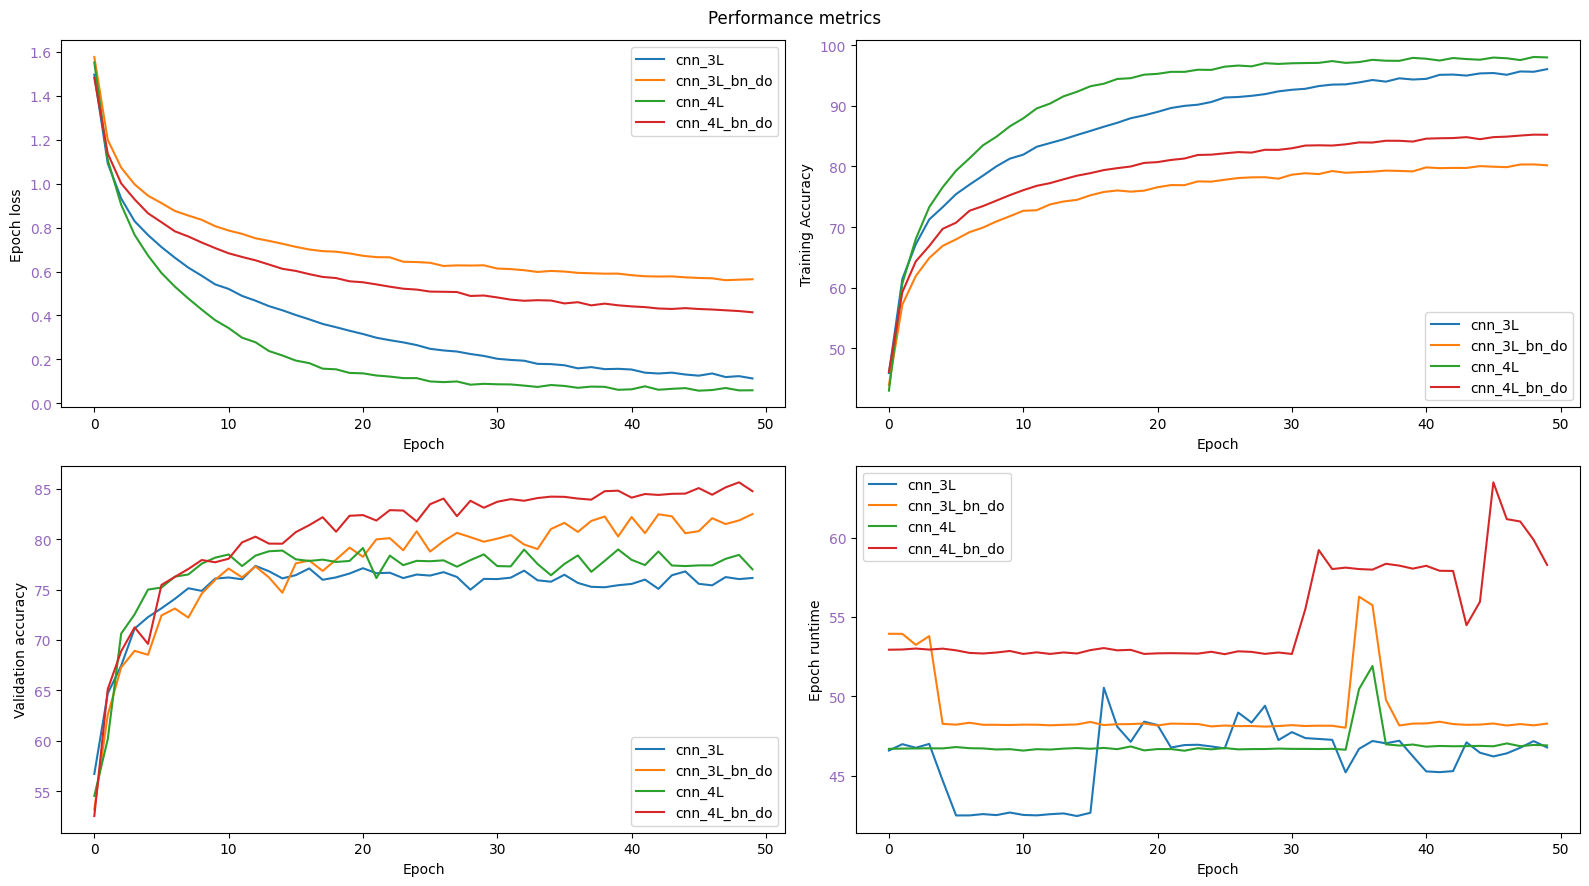

In [69]:
generate_epoch_plots(new_dict)

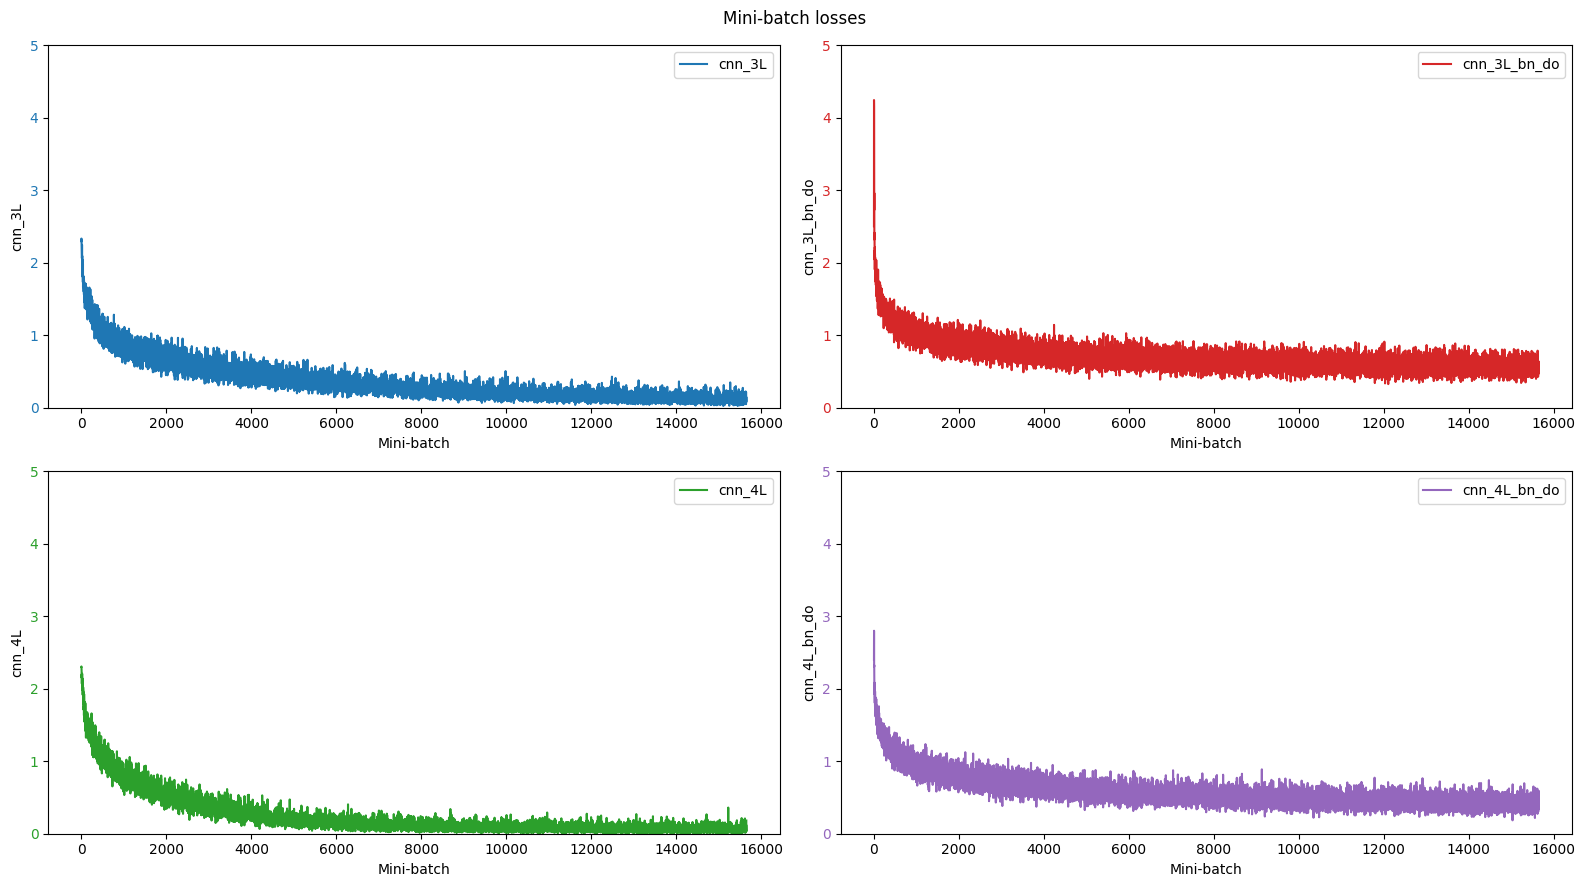

In [67]:
generate_mini_batch_plot(new_dict)

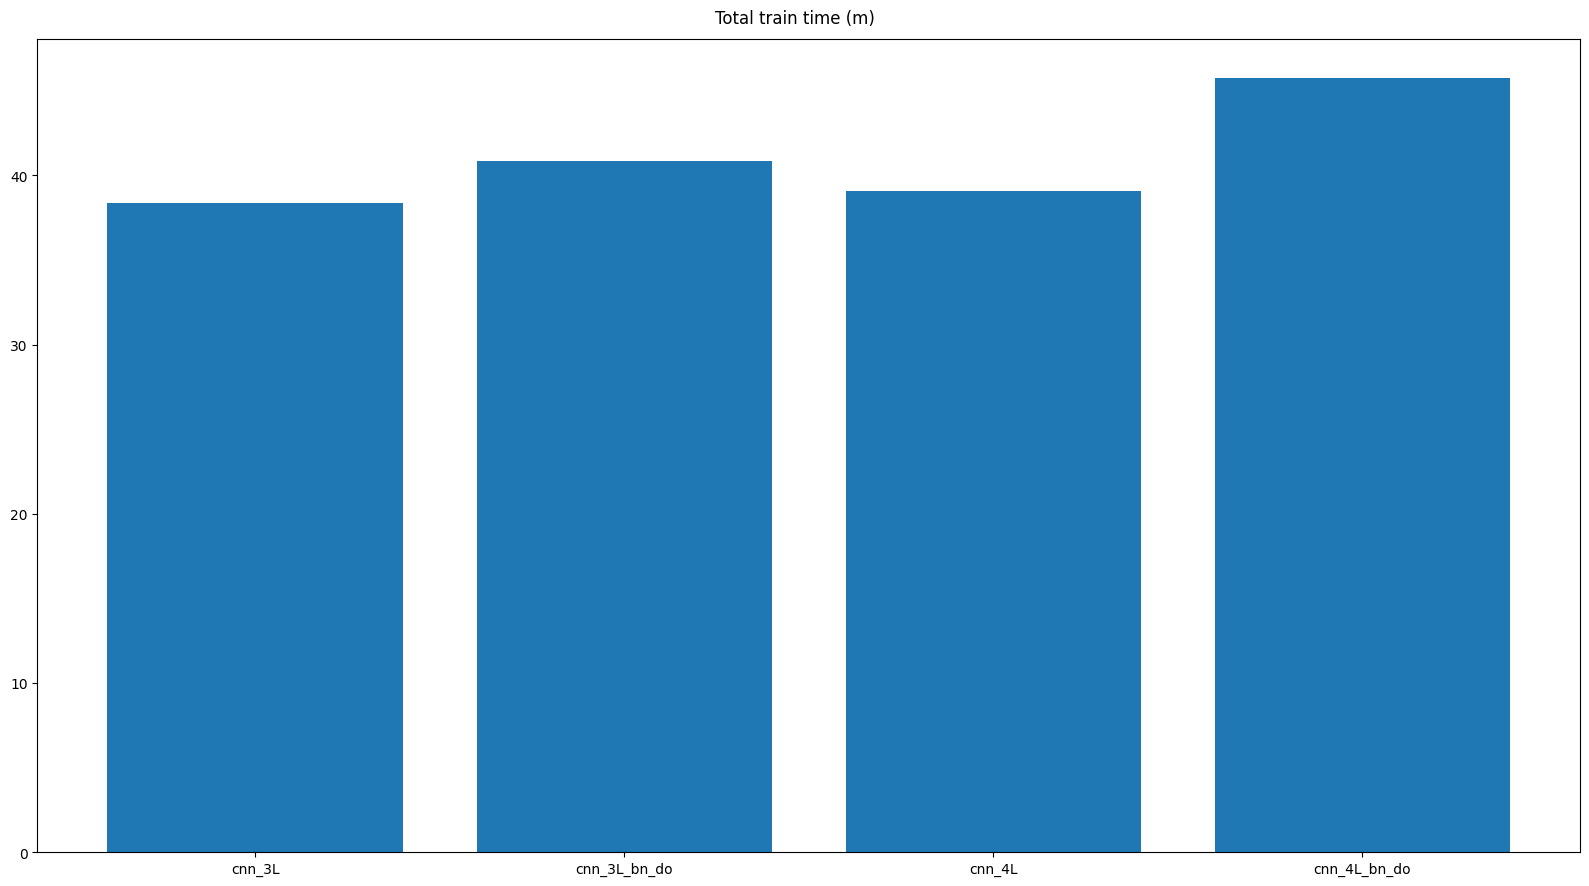

In [88]:
generate_total_runtime_plot(new_dict)

In [102]:
with open('model_performance_after_activations.pickle_softmax', 'rb') as file:
    grid_results_with_activations_softmax = pickle.load(file)

In [103]:
new_dict = switch_dictionary(grid_results_with_activations_softmax)

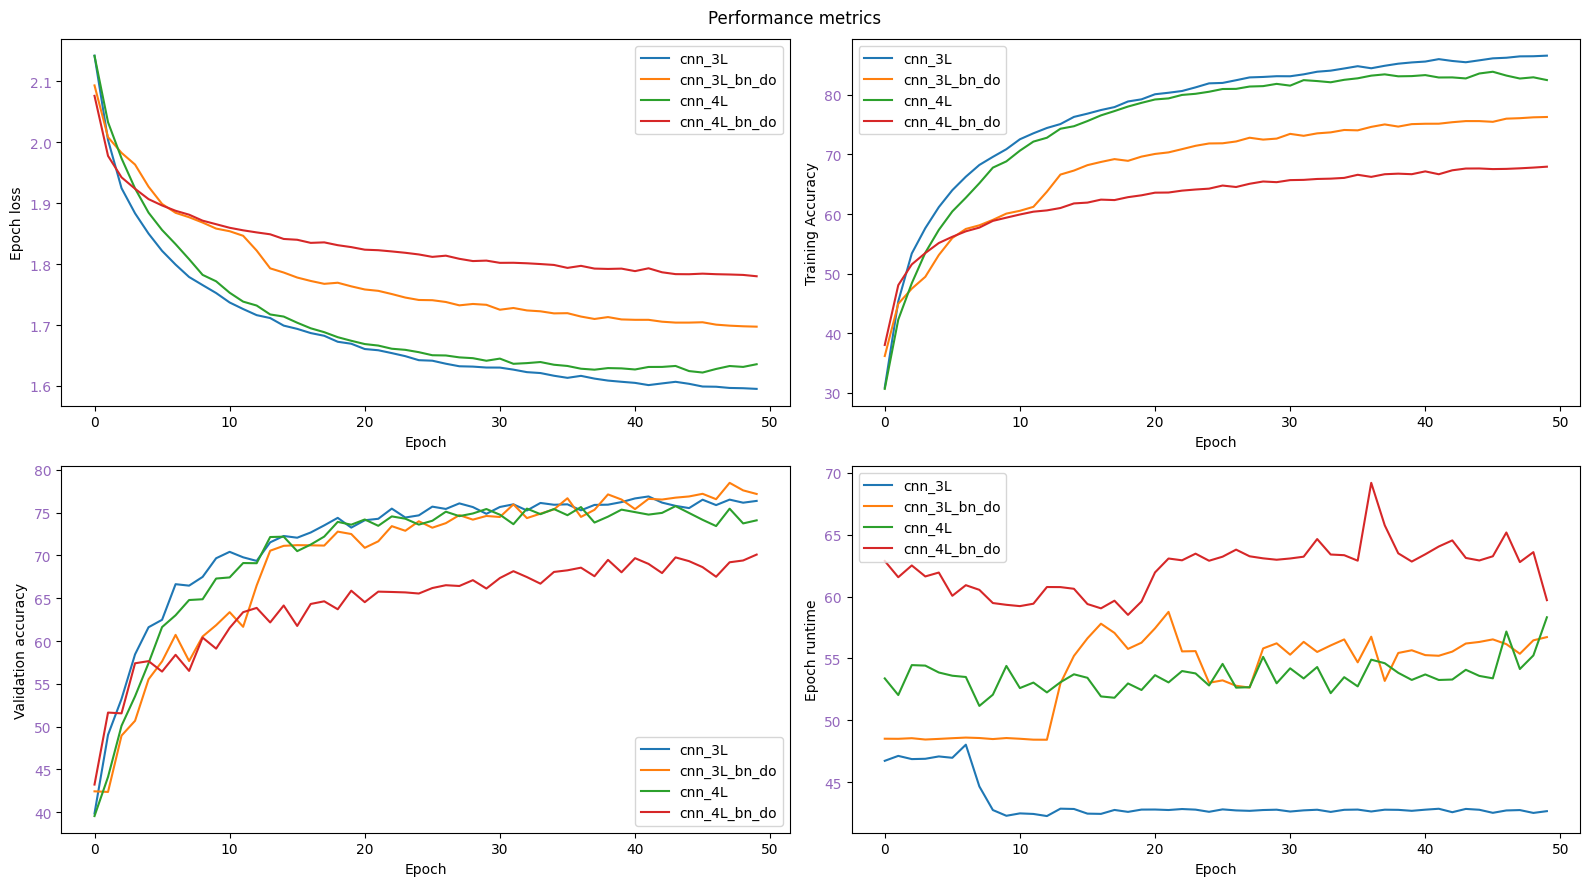

In [104]:
generate_epoch_plots(new_dict)

1.5021321773529053 2.3168139457702637


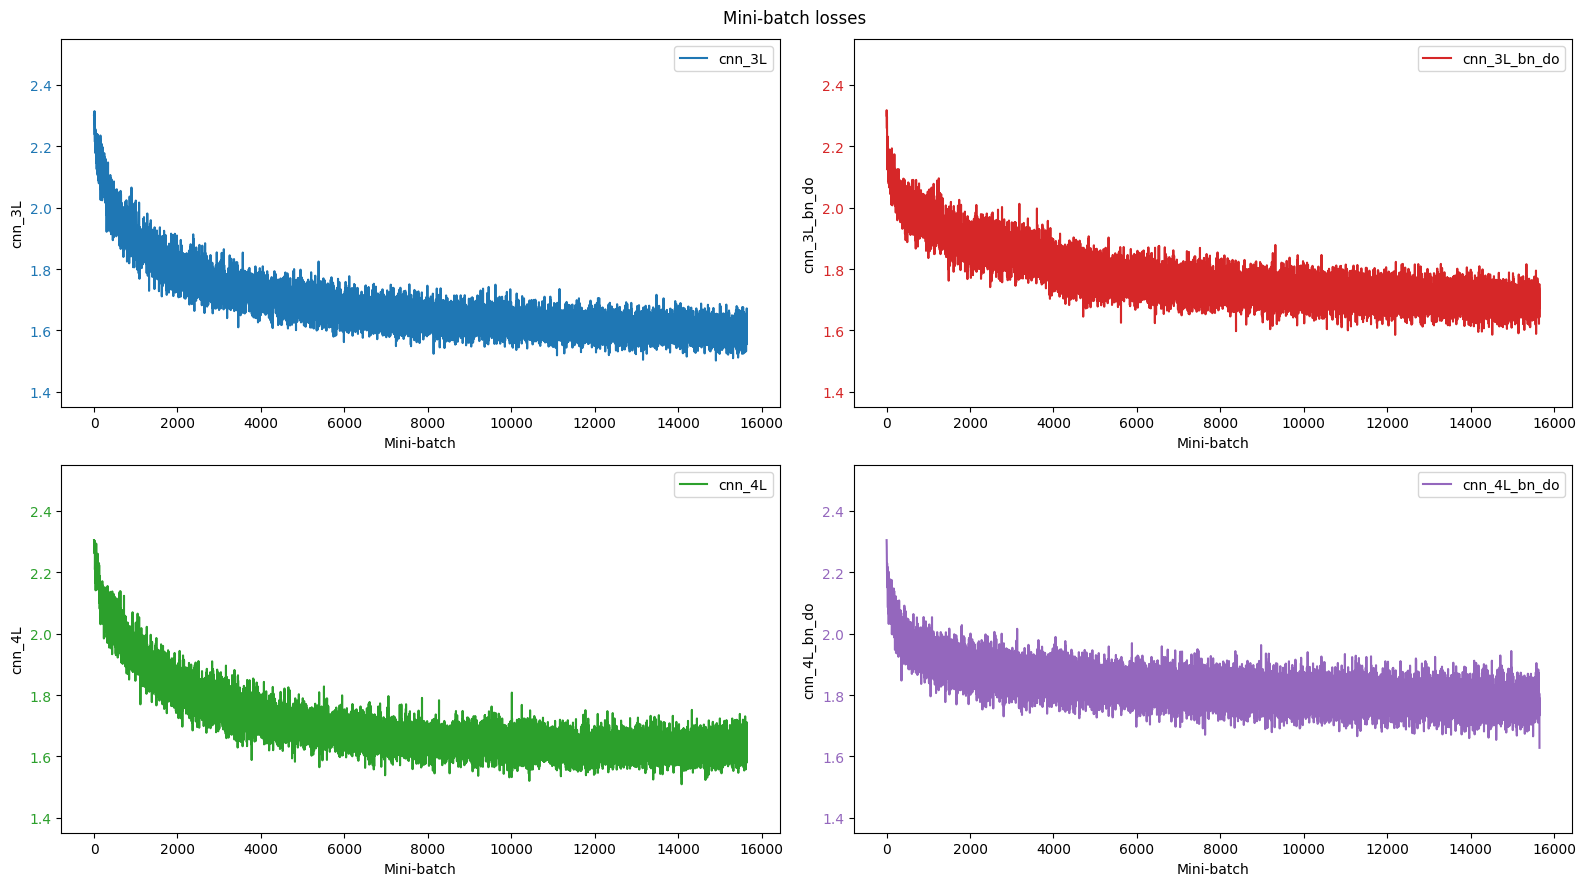

In [105]:
generate_mini_batch_plot(new_dict)

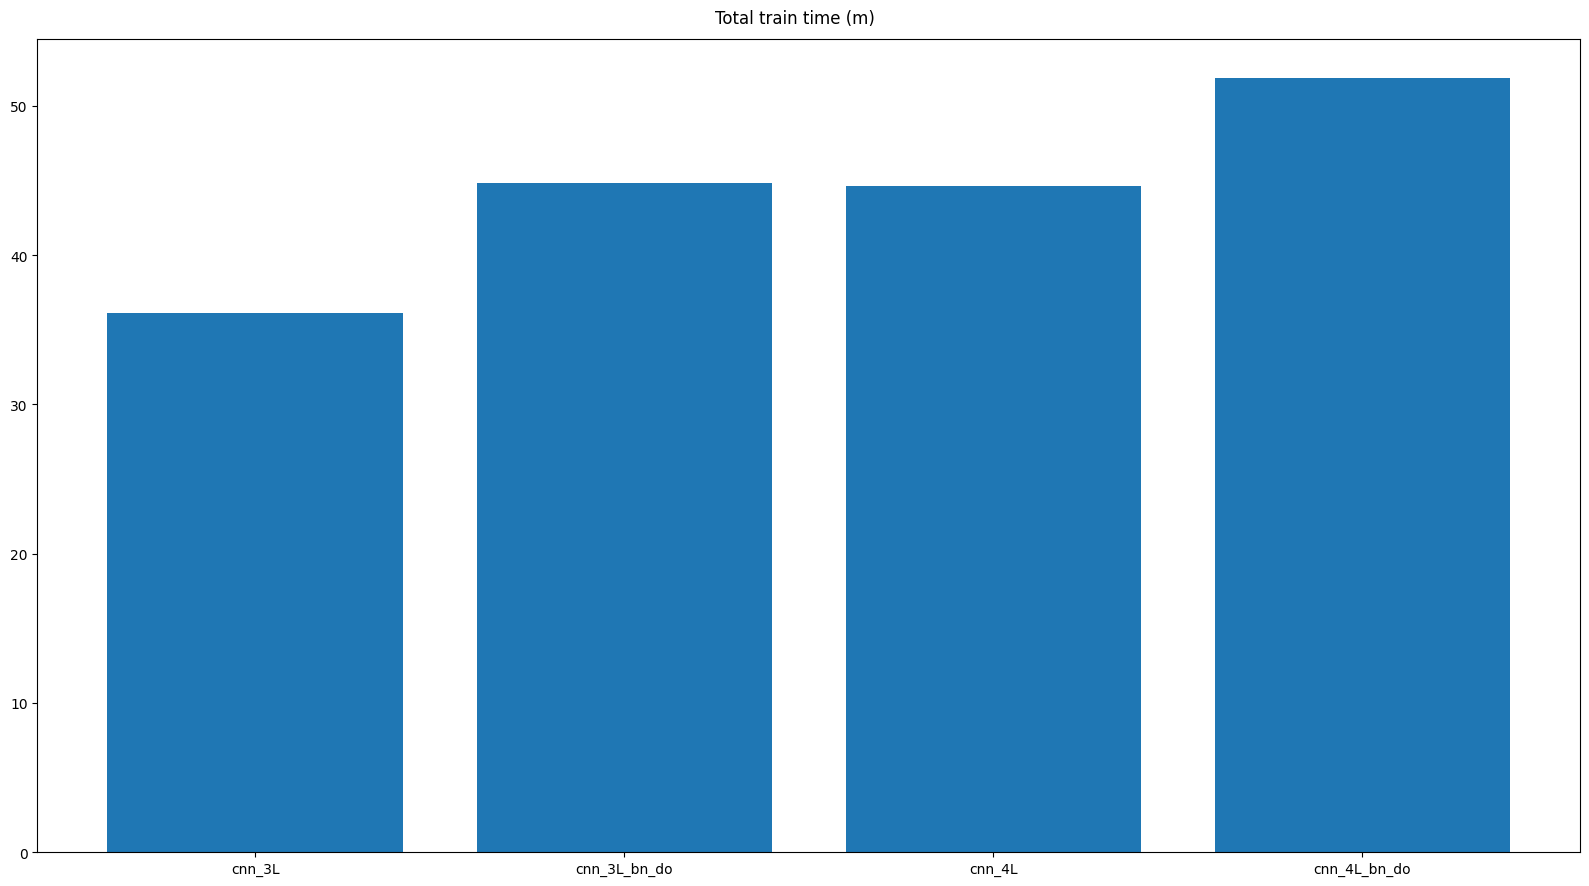

In [106]:
generate_total_runtime_plot(new_dict)

In [94]:
with open('model_performance_after_activations.pickle_sigmoid', 'rb') as file:
    grid_results_with_activations = pickle.load(file)

In [95]:
new_dict = switch_dictionary(grid_results_with_activations)

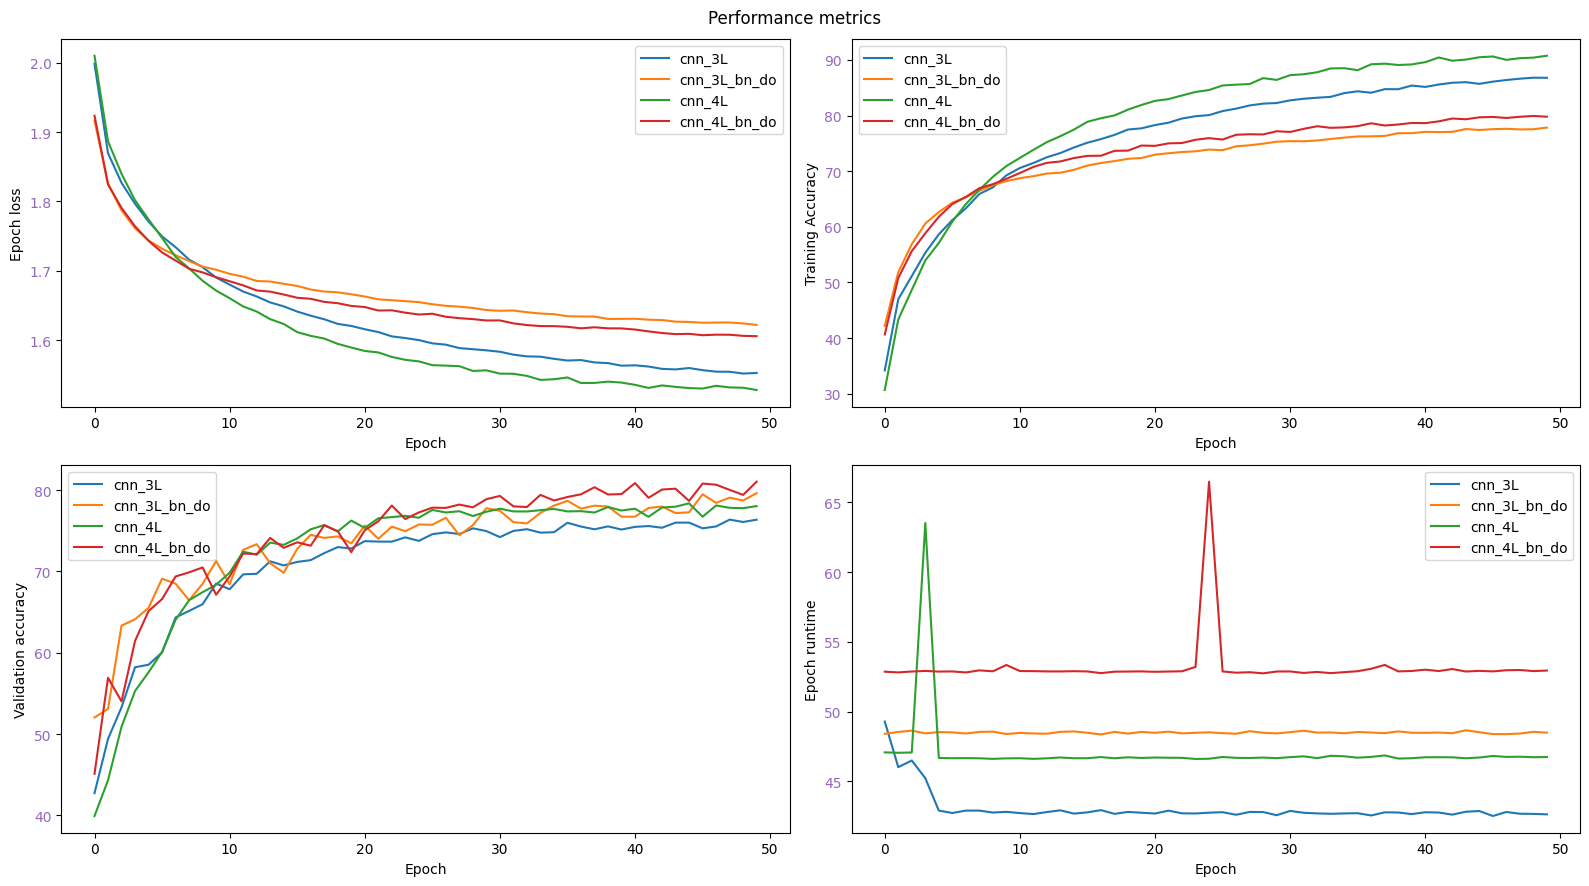

In [96]:
generate_epoch_plots(new_dict)

1.4801199436187744 2.3099944591522217


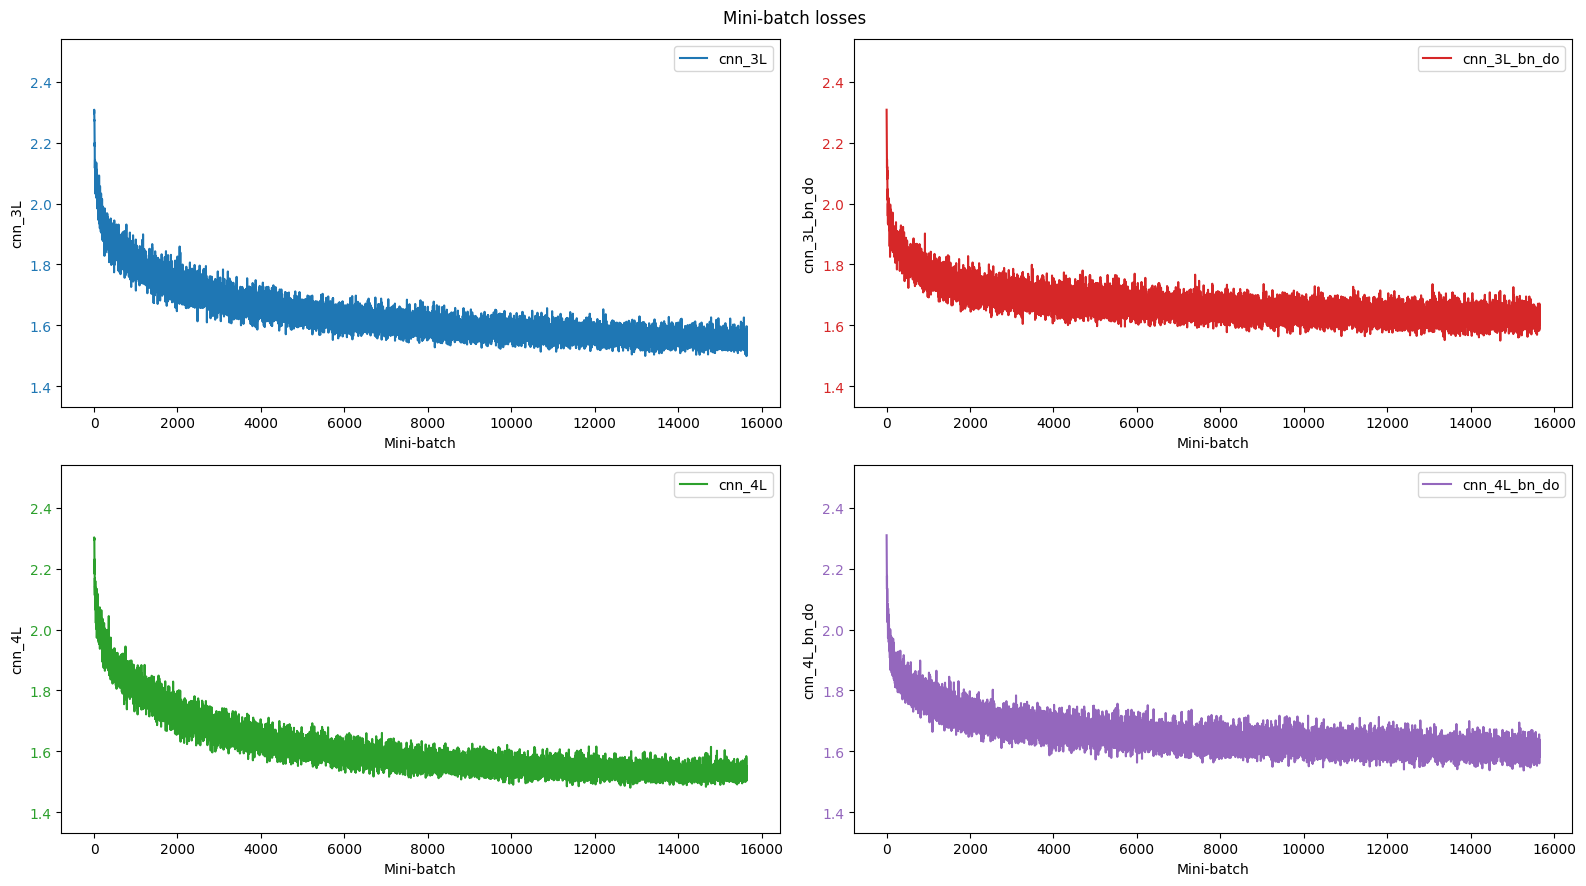

In [100]:
generate_mini_batch_plot(new_dict)

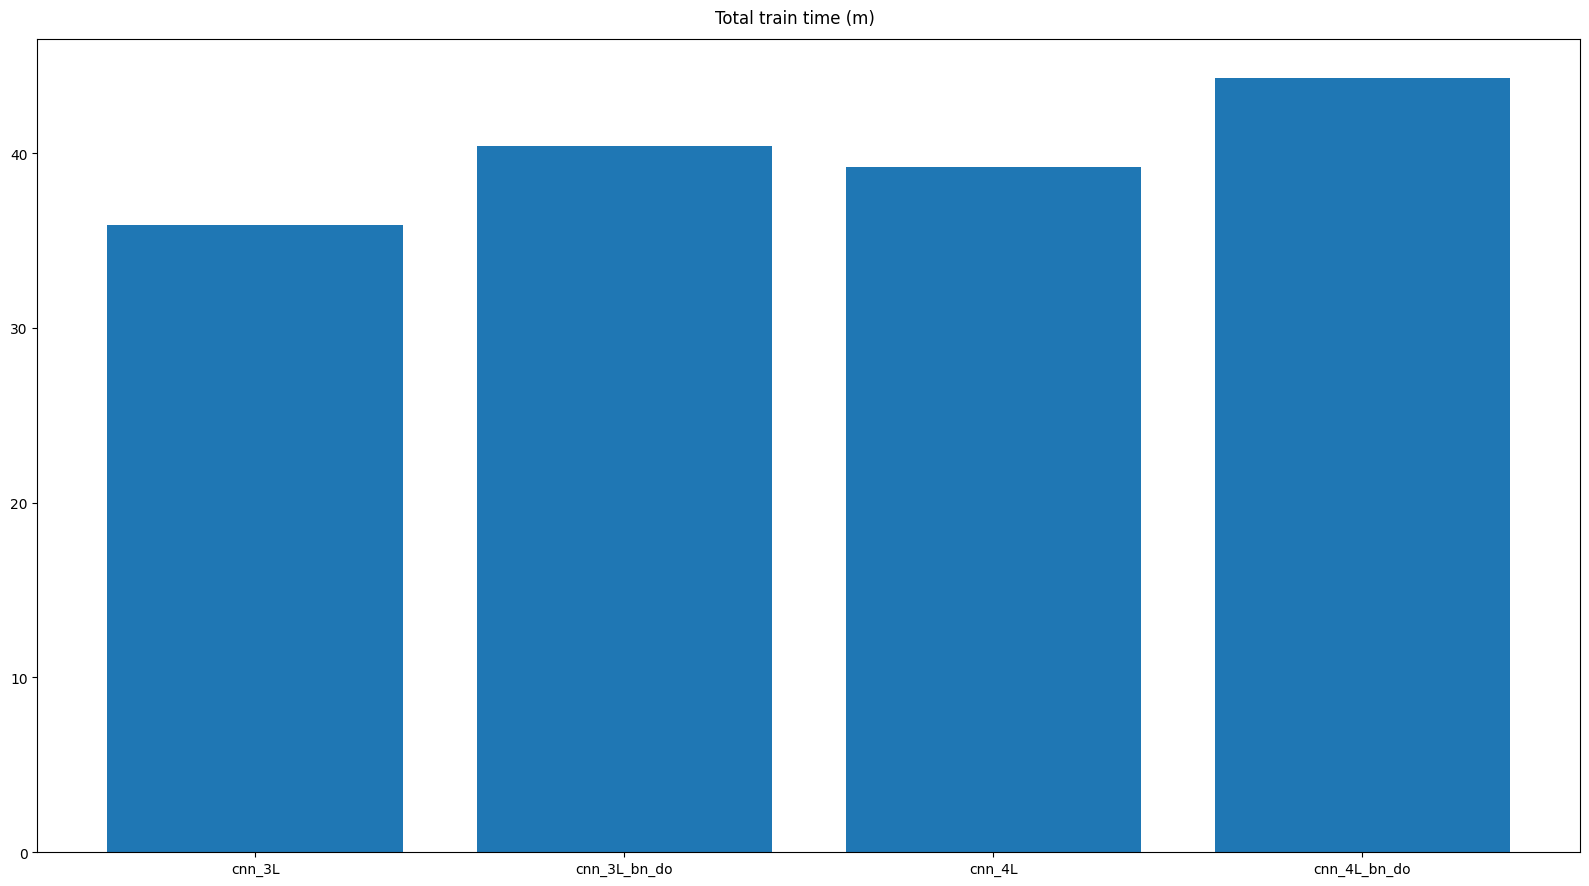

In [98]:
generate_total_runtime_plot(new_dict)

In [109]:
import visualtorch

In [176]:
input_shape = (1, 3, 32, 32)

model = SimpleCNN(num_classes=10, conv_layers=4, batch_norm=True, dropout=True)

img = visualtorch.layered_view(model, input_shape=input_shape, one_dim_orientation="x", legend=True)

------------------------------
* Layers:
Layer 1 output: 16.0*16.0, channels: 32
Layer 2 output: 8.0*8.0, channels: 64
Layer 3 output: 4.0*4.0, channels: 128
Layer 4 output: 2.0*2.0, channels: 256
Linear is 1024.0 to 128
Linear is 128 to 10
* Parameters:
Convolutional layers: 4
Dropout: True
Batch normalization: True
Final image size before Linear FC: 2
Final channels before Linear FC: 256


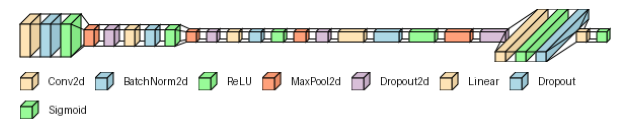

In [177]:
plt.axis('off')
plt.tight_layout()
plt.imshow(img)
plt.show()

### MLP Architecture

- **Input layer**: Flatten 32×32×3 = 3,072 input features
- **Hidden layers**: 2-3 fully connected layers (e.g., 512 → 256 → 128 neurons)
- **Output layer**: 10 classes with softmax
- **Activation**: ReLU
- **Regularization**: Dropout (0.2-0.5) (optional)

### CNN Architecture

- **Convolutional blocks**: 3-4 blocks of Conv → ReLU → MaxPool
    - Block 1: 32 filters, 3×3 kernel
    - Block 2: 64 filters, 3×3 kernel
    - Block 3: 128 filters, 3×3 kernel
- **Fully connected layers**: 1-2 dense layers (128 → 10)
- **Regularization**: Dropout, Batch Normalization

In [139]:
class MLP(nn.Module):
    def __init__(self, num_classes=10, layers=3, batch_norm=False, dropout=False):
        super(MLP, self).__init__()

        print('-'*30)
        print('* Layers:')
        
        self.fc1 = nn.Linear(3 * 32 * 32, 512)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)
        
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2 if layers == 2 else 0.5)
        
        self.fc3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.5)

        last_layer_input = 128 if layers == 3 else 256 
        self.fc4 = nn.Linear(last_layer_input, num_classes)
        self.sigmoid = nn.Sigmoid()

        self.layers = layers
        self.batch_norm = batch_norm
        self.dropout = dropout

        print('* Parameters:')
        print(f'Layers: {self.layers}')
        print(f'Dropout: {self.dropout}')
        print(f'Last layer input: {last_layer_input}')        

    def forward(self, x):
        x = x.view(-1, 3 * 32 * 32) # Flatten the image
        
        x = self.relu1(self.fc1(x))
        x = (self.dropout1(x) if self.dropout else x)
        x = self.relu2(self.fc2(x))
        x = (self.dropout2(x) if self.dropout else x)
        
        if self.layers == 3:
            x = self.relu3(self.fc3(x))
            x = (self.dropout3(x) if self.dropout else x)
            
        x = self.fc4(x)
        x = self.sigmoid(x)
        return x

In [146]:
input_shape = (1, 3, 32, 32)

model = MLP(num_classes=10, layers=3, batch_norm=True, dropout=True)

img = visualtorch.layered_view(model, input_shape=input_shape, one_dim_orientation="x", legend=True)

------------------------------
* Layers:
* Parameters:
Layers: 3
Dropout: True
Last layer input: 128


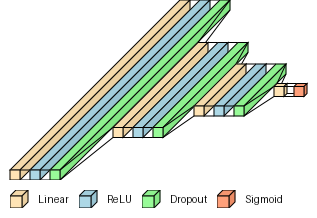

In [147]:
img

### Softmax results

In [157]:
with open('grid_results_mlp_softmax.pickle', 'rb') as file:
    grid_results_mlp_sigmoid = pickle.load(file)

In [158]:
new_dict = switch_dictionary(grid_results_mlp_sigmoid)

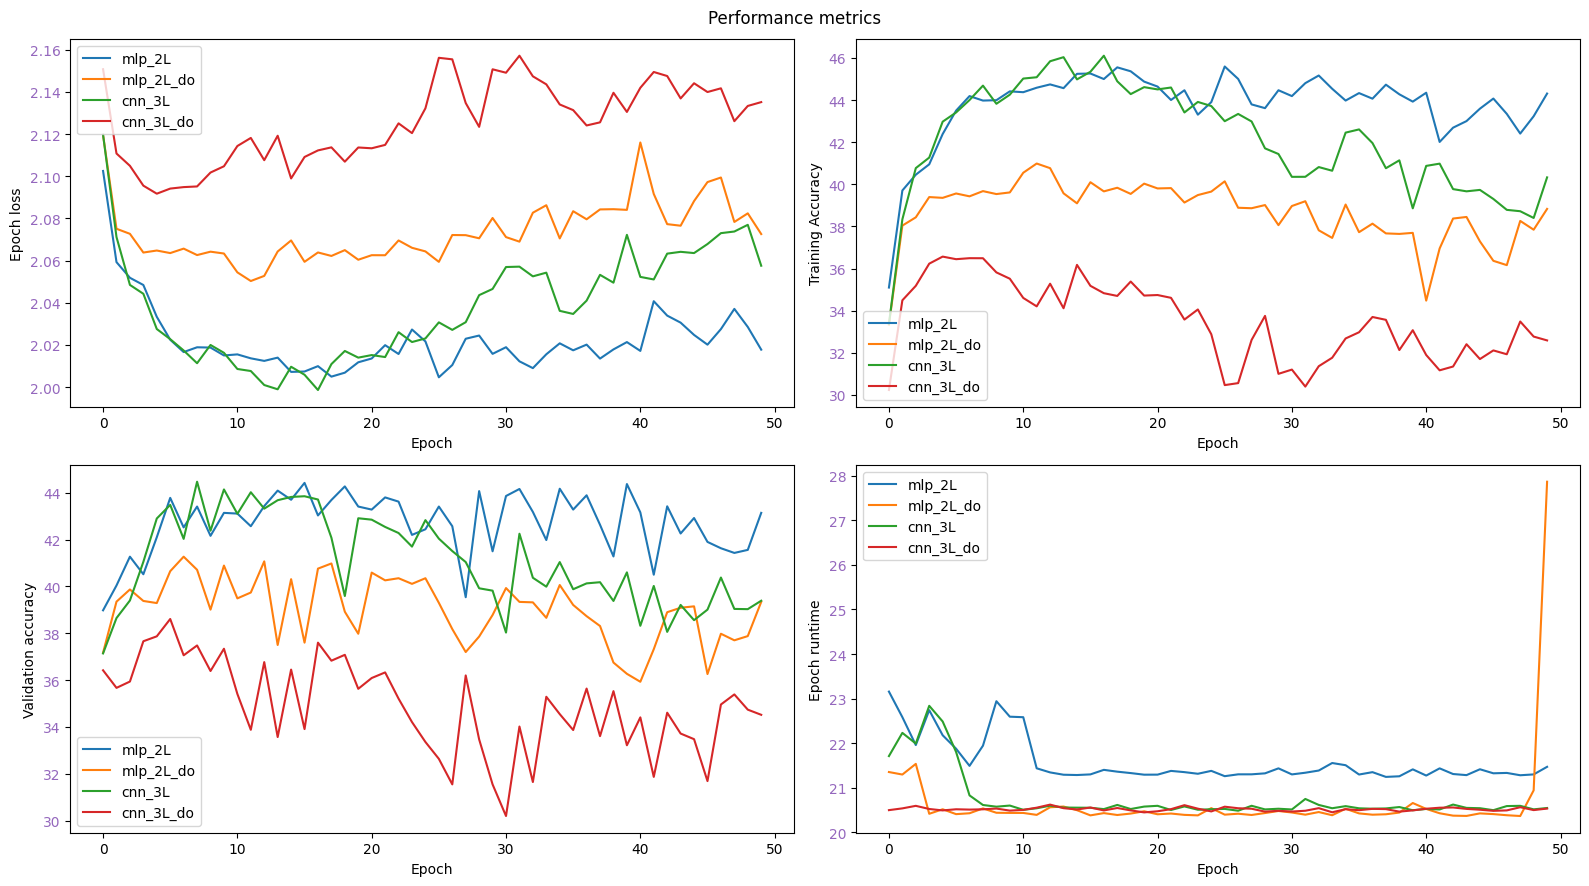

In [159]:
generate_epoch_plots(new_dict, 'mlp_performance_softmax.png')

1.8248207569122314 2.303250789642334


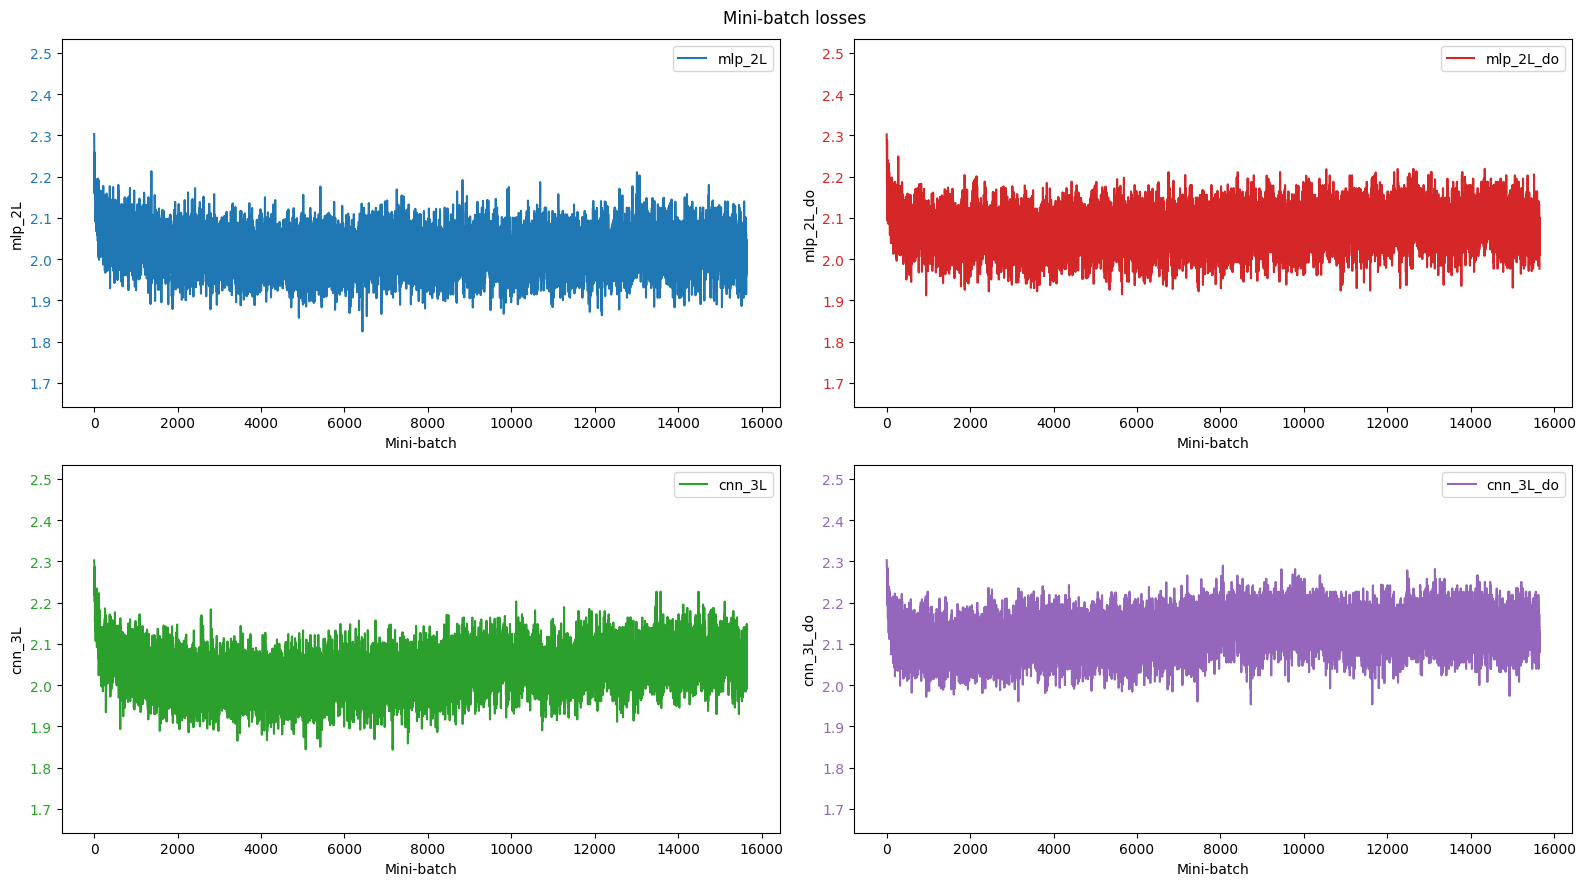

In [160]:
generate_mini_batch_plot(new_dict, 'mlp_batch_losses_softmax.png')

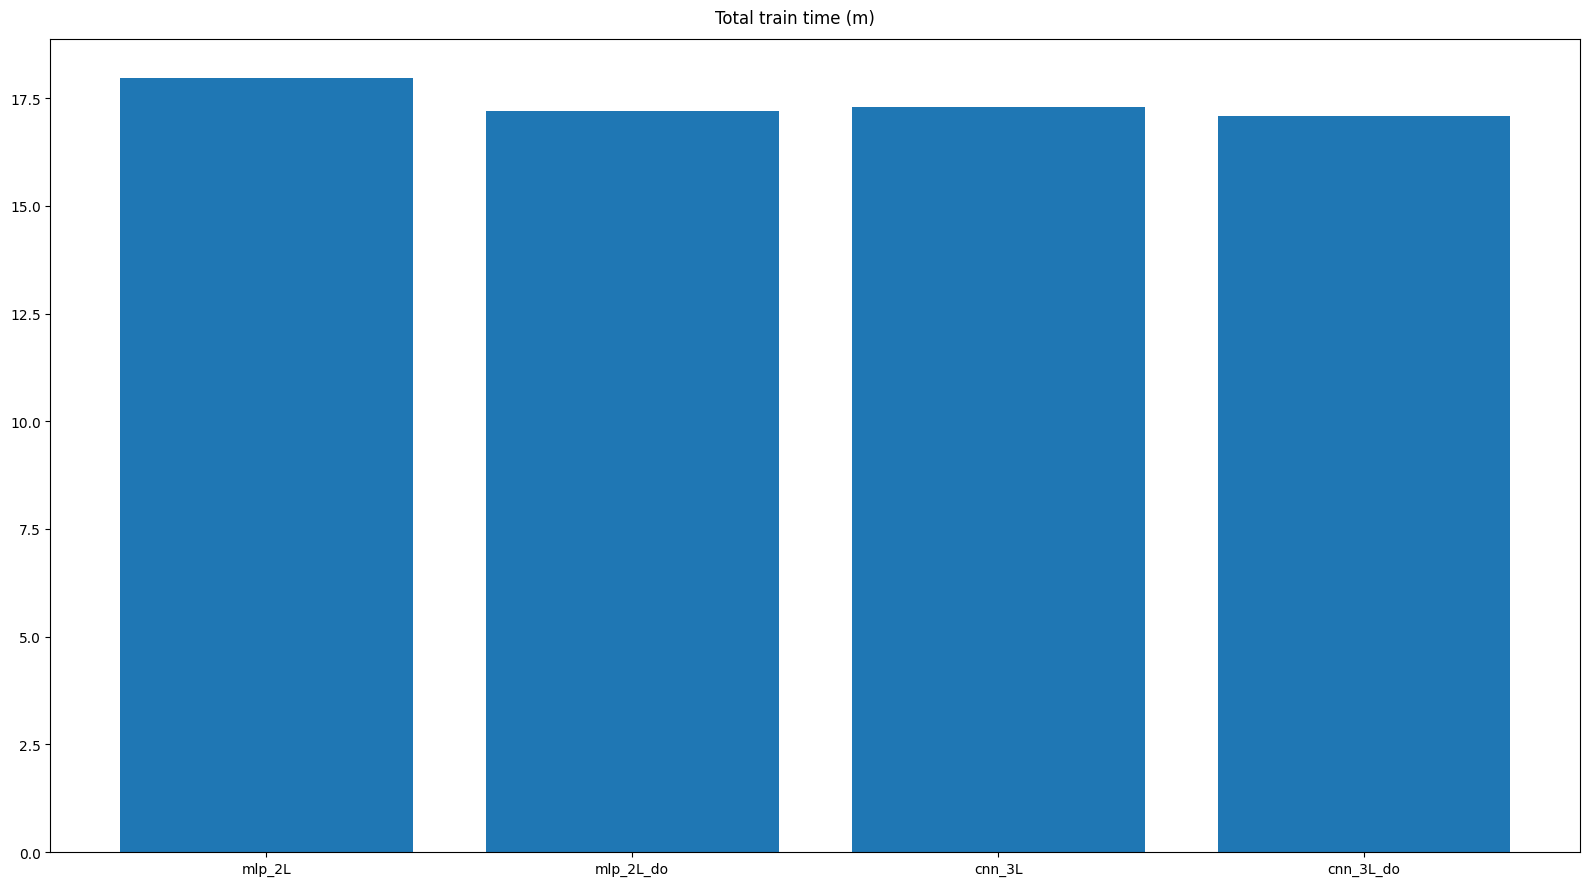

In [161]:
generate_total_runtime_plot(new_dict, 'mlp_train_times_softmax.png')

### Sigmoid

In [162]:
with open('grid_results_mlp_sigmoid.pickle', 'rb') as file:
    grid_results_with_activations = pickle.load(file)

In [164]:
new_dict = switch_dictionary(grid_results_with_activations)

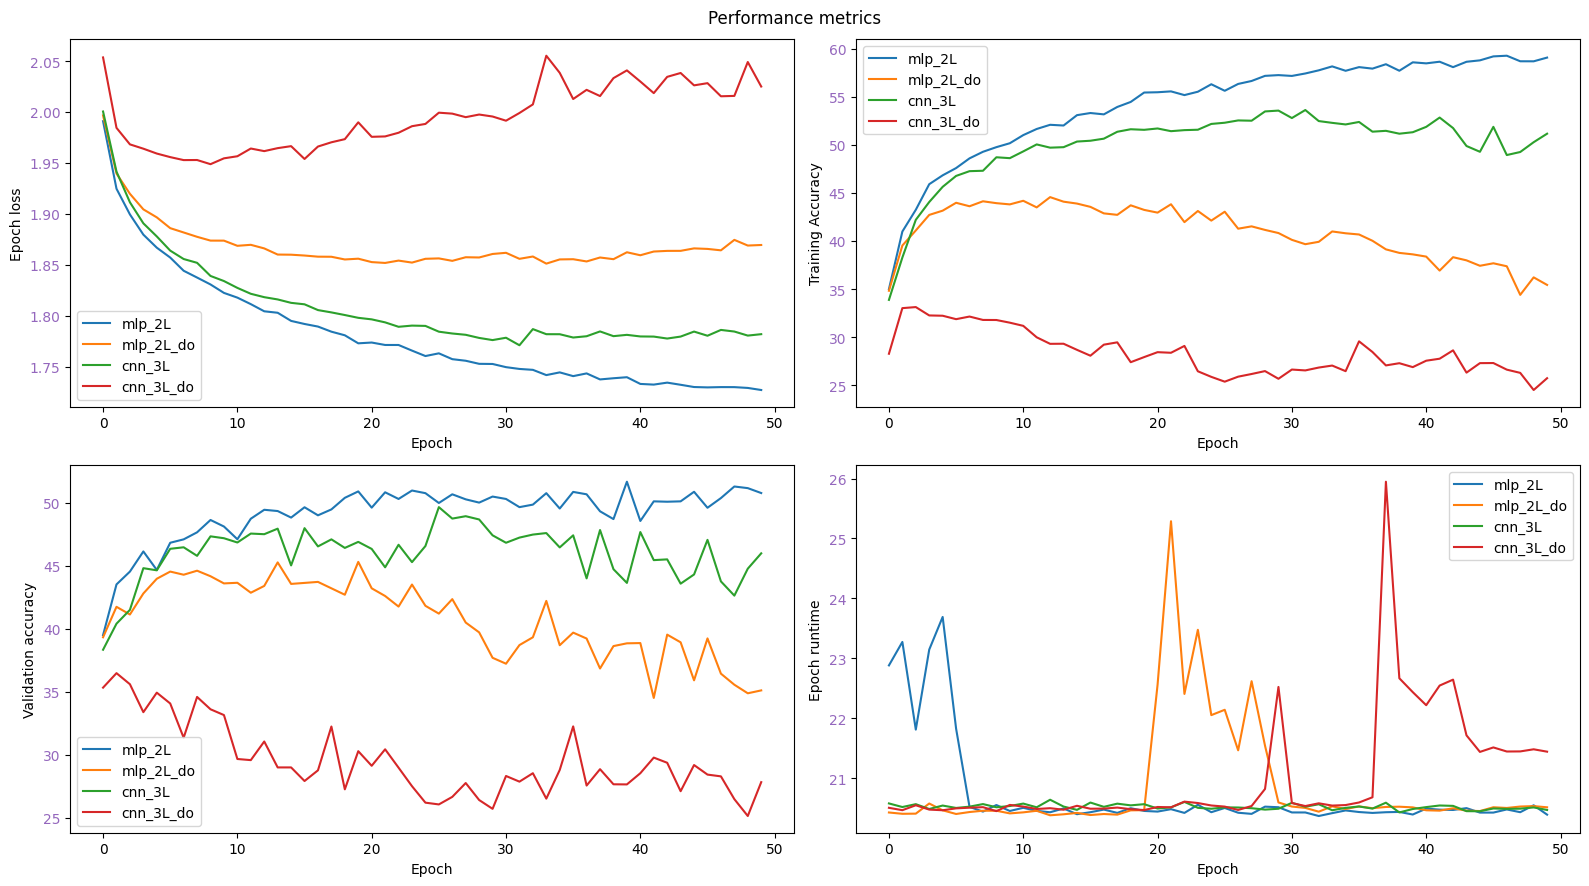

In [165]:
generate_epoch_plots(new_dict, 'mlp_performance_sigmoid.png')

1.636532187461853 2.302098274230957


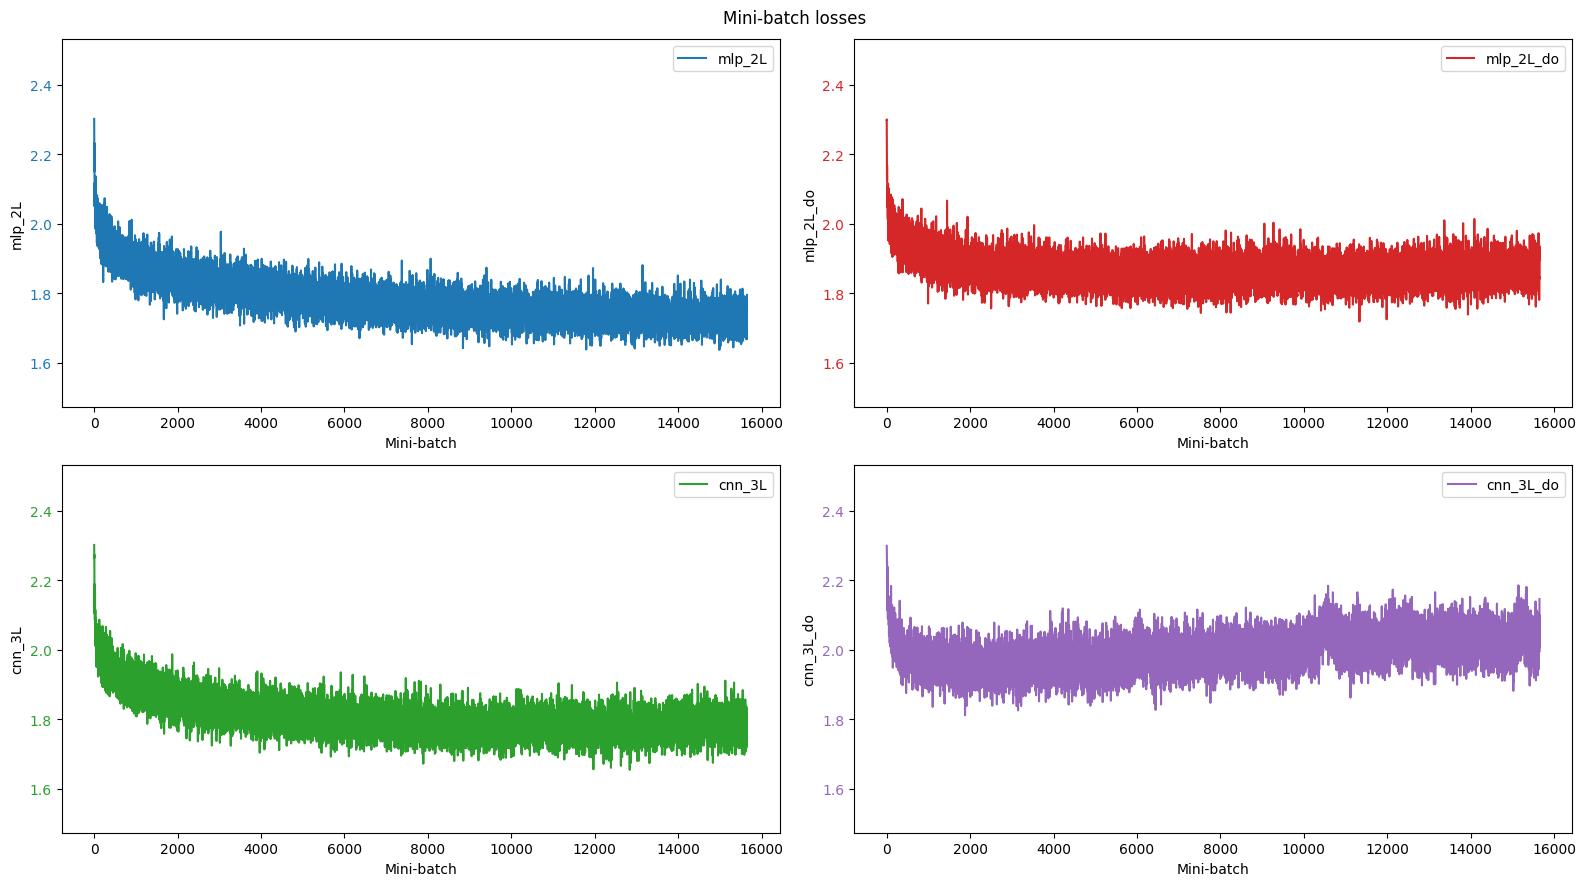

In [166]:
generate_mini_batch_plot(new_dict, 'mlp_performance_sigmoid.png')

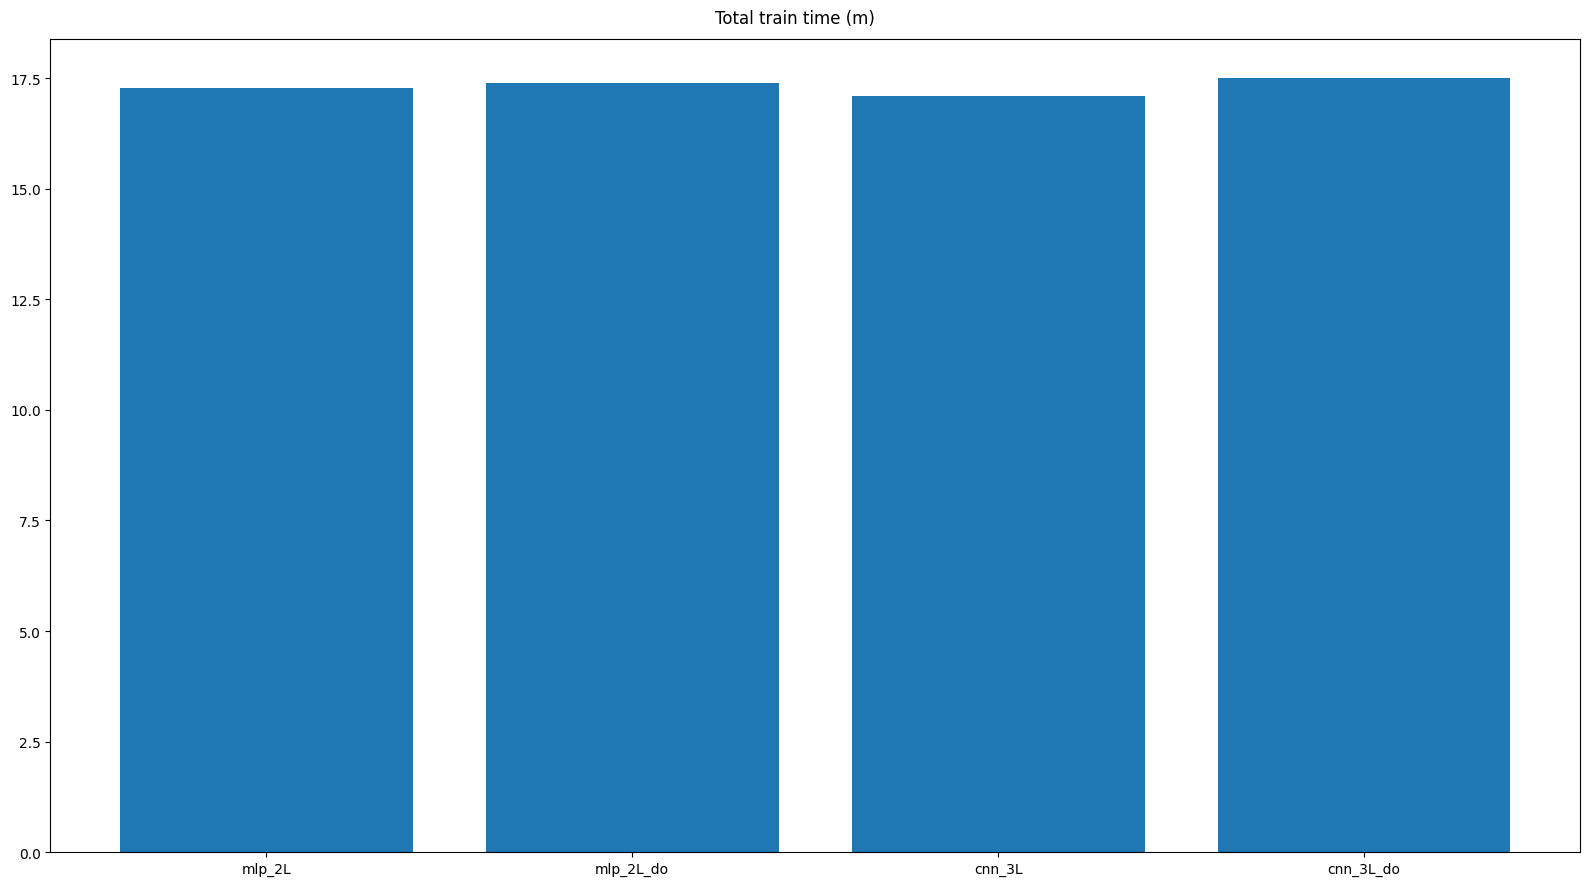

In [167]:
generate_total_runtime_plot(new_dict)